### Лабораторная работа №3
#### Ковалев А.В. ИУ5-63Б
1. Импорт библиотек.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.tree import export_graphviz
from io import StringIO 
from operator import itemgetter

2. Загрузка и первичный анализ данных

In [160]:
smartphones = pd.read_csv('smartphone_specifications_and_prices.csv', sep=",")
print('Кол-во строк: ', smartphones.shape[0],'\n' ,'Кол-во столбцов: ', smartphones.shape[1], sep = '')
print(smartphones.dtypes)
print('Пропуски по столбцам:', smartphones.isnull().sum())
smartphones.head(8)

Кол-во строк: 1256
Кол-во столбцов: 10
brand_name           object
model                object
display              object
front_camera         object
rare_camera          object
processor            object
battery_capacity     object
ram                 float64
internal_storage      int64
price               float64
dtype: object
Пропуски по столбцам: brand_name          0
model               0
display             0
front_camera        0
rare_camera         0
processor           9
battery_capacity    0
ram                 0
internal_storage    0
price               0
dtype: int64


,brand_name,model,display,front_camera,rare_camera,processor,battery_capacity,ram,internal_storage,price
0,SAMSUNG,Samsung S24 Ultra,"6.8"" (120Hz)",40MP,108MP + 10MP + 10MP + 12MP,Exynos,5000 mAh,8.0,128,334999.0
1,SAMSUNG,Samsung S24 Plus,"6.6"" (120Hz)",10MP,50MP + 10MP + 12MP,Exynos,4500 mAh,8.0,128,189999.0
2,SAMSUNG,Samsung Zero,"6.41"" (120Hz)",32 MP,12 MP + 8 MP + 12 MP,Snapdragon 888 5G,4500 mAh,8.0,256,112999.0
3,SAMSUNG,Samsung S24,"6.1"" (120Hz)",10MP,50MP + 10MP + 12MP,Exynos,3700 mAh,8.0,128,249999.0
4,SAMSUNG,Samsung A05s,"6.5"" (90Hz)",5MP,50MP + 2MP + 2MP,Exynos,5000 mAh,4.0,64,24999.0
5,SAMSUNG,Samsung A05,"6.5""",5MP,50MP + 2MP,Mediatek,5000 mAh,4.0,64,24999.0
6,SAMSUNG,Samsung Z Flip 5,"6.7"" (120Hz)",10MP,12MP + 12MP,Snapdragon,3700 mAh,8.0,128,295999.0
7,SAMSUNG,Samsung M14,"6.6"" (90 (unconfirmed)Hz)",8 MP,50MP + 8MP + 2MP (not confirmed),Exynos,5000 mAh,4.0,64,34999.0


In [161]:
import re
smartphones = smartphones.dropna(subset=['processor'])
#smartphones = smartphones.drop('model', axis=1)

def list_replace(object: str, replacements: dict) -> str:
    result = None
    for replacement in replacements["replacements"]:
        object.replace(replacements["key"], replacements["value"],)
    return result

def get_display_diagonal(display: str) -> float|None:
    return float(display.split("\"")[0])

def get_display_fps(display: str) -> float|None:
    splitted = re.split(r'[()]+', display)
    if len(splitted) < 2:
        return None
    return float(splitted[1].replace('Hz', ''))

def get_f_cam_mp(front_cam: str) -> int|None:
    front_cameras = list_replace(front_cam, {"replacements":
                                             [{"key":'MP', "value":''}, {"key":' ', "value":''}
                                              ]})
    if 'Unspecified' in front_cameras:
        return None
    if '+' not in front_cameras:
        return int(front_cameras)
    else:
        return int(max([int(front_cam) for front_cam in front_cameras.split('+')]))

preparations = {"preparations":[{"new_col":"diagonal", "old_col":'display', "func":get_display_diagonal}, 
                                {"new_col":"fps", "old_col":'display', "func":get_display_fps},
                                {"new_col":"f_cam_mp", "old_col":'front_camera', "func":get_f_cam_mp}]}

for preparation in preparations["preparations"]:
    smartphones[preparation["new_col"]] = smartphones[preparation["old_col"]].apply(preparation["func"])
    smartphones = smartphones.dropna(subset=[preparation["new_col"]])

KeyError: 'key'

In [ ]:
smartphones = smartphones.dropna(subset=['fps', 'diagonal'])
print(smartphones["diagonal"])
print(smartphones["fps"])

0       6.80
1       6.60
2       6.41
3       6.10
4       6.50
        ... 
1192    6.55
1193    6.55
1194    6.50
1195    6.50
1201    6.50
Name: diagonal, Length: 555, dtype: float64
0       120.0
1       120.0
2       120.0
3       120.0
4        90.0
        ...  
1192     90.0
1193     90.0
1194     90.0
1195     90.0
1201     90.0
Name: fps, Length: 555, dtype: float64


In [162]:
students = pd.read_csv('Student_performance_data _.csv', sep=",")
print('Кол-во строк: ', students.shape[0],'\n' ,'Кол-во столбцов: ', students.shape[1], sep = '')
print(students.dtypes)
print('Пропуски по столбцам:', students.isnull().sum())
students.head(8)

Кол-во строк: 2392
Кол-во столбцов: 15
StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object
Пропуски по столбцам: StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
5,1006,18,0,0,1,8.191219,0,0,1,1,0,0,0,3.084184,1.0
6,1007,15,0,1,1,15.601680,10,0,3,0,1,0,0,2.748237,2.0
7,1008,15,1,1,4,15.424496,22,1,1,1,0,0,0,1.360143,4.0


3. Выбор необходимых столбцов

<Axes: >

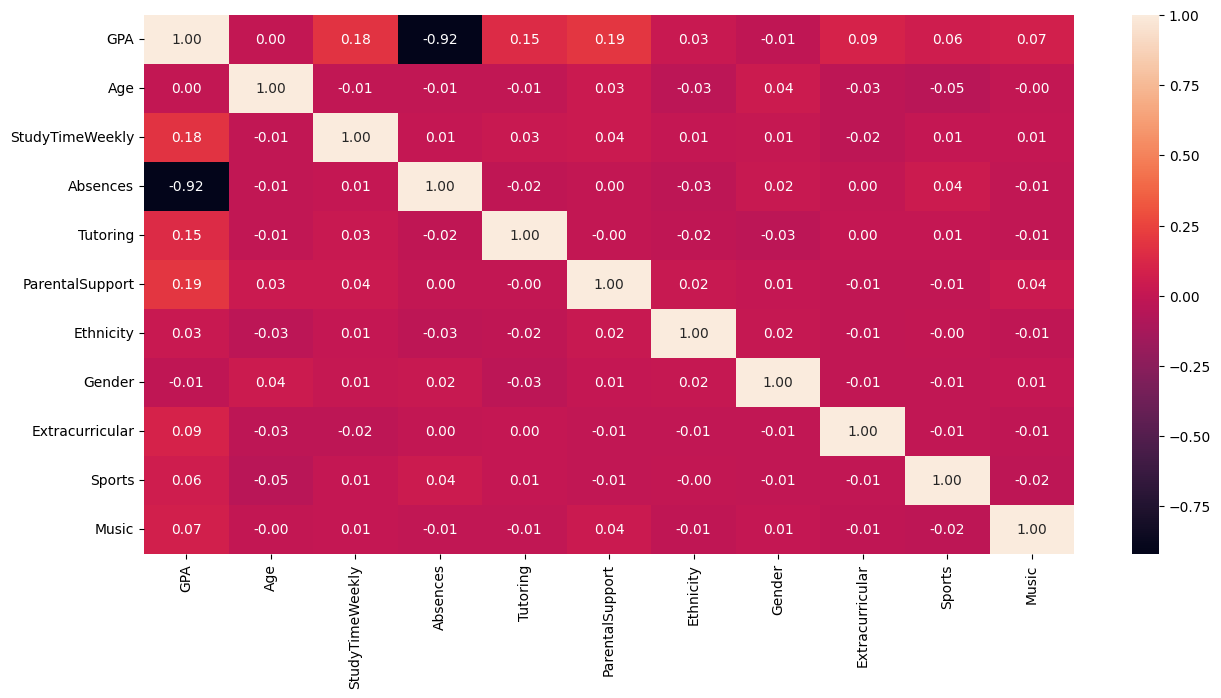

In [163]:
students_nec = students[["GPA", "Age", "StudyTimeWeekly", "Absences", "Tutoring", 
                         "ParentalSupport", "Ethnicity", "Gender", "Extracurricular", "Sports", "Music"]]


fig, ax = plt.subplots(figsize=(15,7))
sns.heatmap(students_nec.corr(method='pearson'), ax=ax, annot=True, fmt='.2f')

4. Выбор необходимых столбцов и составление тестовой выборки

In [ ]:

GPA_X_train, GPA_X_test, GPA_y_train, GPA_y_test = train_test_split(
    students[["Age", "StudyTimeWeekly", "Absences", "Tutoring", 
                         "ParentalSupport", "Ethnicity", "Gender", "Extracurricular", "Sports", "Music"]], 
                         students["GPA"], test_size=0.2, random_state=1)

"""GPA_X_train, GPA_X_test, GPA_y_train, GPA_y_test = train_test_split(
    students[["StudyTimeWeekly", "Absences", "Tutoring", "ParentalSupport"]], 
    students["GPA"], test_size=0.2, random_state=1)"""

print(len(GPA_X_train.columns))

10


4. Функции для отрисовки диаграмм и графиков

In [169]:
import graphviz

def draw_feature_importances(tree_model, X_dataset, figsize=(10,5)):
    """
    Вывод важности признаков в виде графика
    """
    # Сортировка значений важности признаков по убыванию
    list_to_sort = list(zip(X_dataset.columns.values, tree_model.feature_importances_))
    sorted_list = sorted(list_to_sort, key=itemgetter(1), reverse = True)
    # Названия признаков
    labels = [x for x,_ in sorted_list]
    # Важности признаков
    data = [x for _,x in sorted_list]
    # Вывод графика
    fig, ax = plt.subplots(figsize=figsize)
    ind = np.arange(len(labels))
    plt.bar(ind, data)
    plt.xticks(ind, labels, rotation='vertical')
    # Вывод значений
    for a,b in zip(ind, data):
        plt.text(a-0.05, b+0.01, str(round(b,3)))
    plt.show()
    return labels, data

def render_png_tree(tree_model_param, feature_names_param, file_name, directory):
    dot_data = StringIO()
    export_graphviz(tree_model_param, out_file=dot_data, feature_names=feature_names_param,
                    filled=True, rounded=True, special_characters=True)
    graph = graphviz.Source(dot_data.getvalue())
    graph.render(directory=directory, filename=file_name, format='png', view=False)

5. Случайный лес

1913 1913 479 479


d:\MLtech\env\Lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


0.6371274778576714 0.36287252214232857


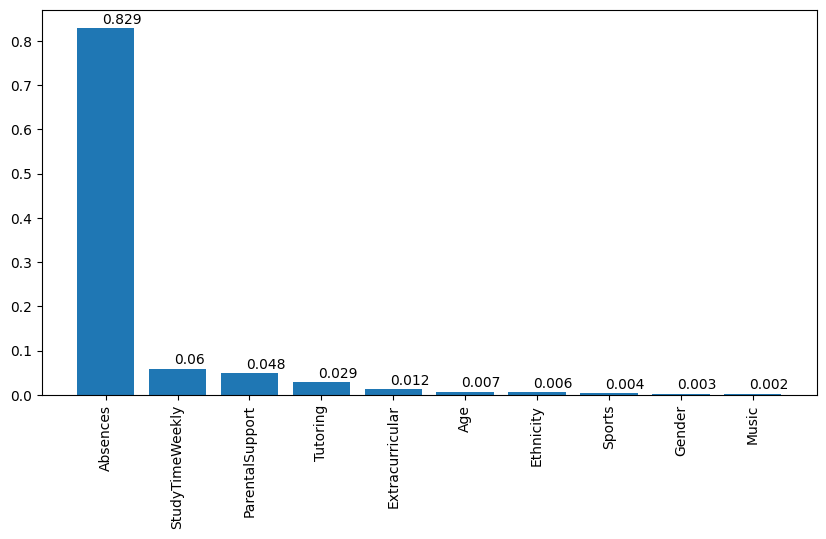

In [170]:
from sklearn.ensemble import RandomForestRegressor

RANDOM_TREE_N_ESTIMATORS=9

random_tree = RandomForestRegressor(n_estimators=RANDOM_TREE_N_ESTIMATORS, oob_score=True, random_state=10, max_features='sqrt', min_samples_leaf=16)
print(len(GPA_X_train), len(GPA_y_train), len(GPA_X_test), len(GPA_y_test))
random_tree.fit(GPA_X_train, GPA_y_train)

for i in range(RANDOM_TREE_N_ESTIMATORS):
    render_png_tree(random_tree.estimators_[i], GPA_X_train.columns, f"random_tree_{i}", "renders/random_tree")

print(random_tree.oob_score_, 1-random_tree.oob_score_)
_,_ = draw_feature_importances(random_tree, GPA_X_train)

7. Бэггинг

d:\MLtech\env\Lib\site-packages\sklearn\ensemble\_bagging.py:1315: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(


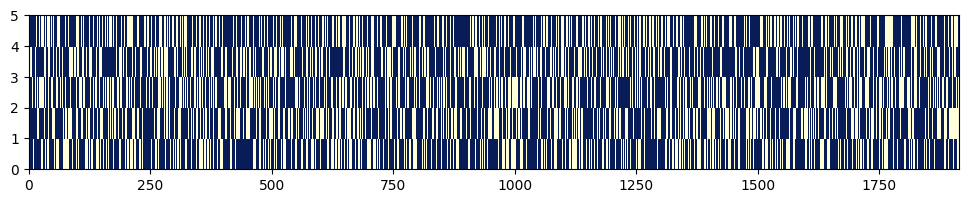

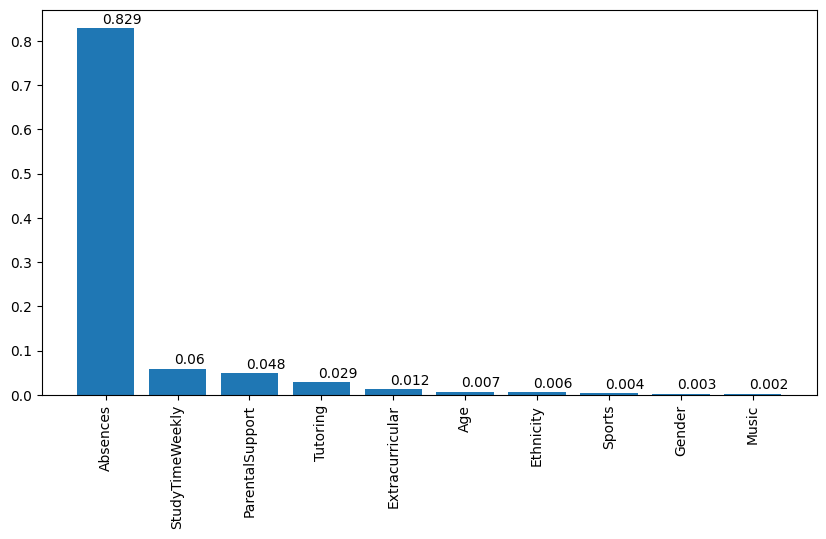

(0.7890053431733942, 0.2109946568266058)

In [171]:
from sklearn.ensemble import BaggingRegressor

BAGGING_N_ESTIMATORS=9

bagging = BaggingRegressor(n_estimators=BAGGING_N_ESTIMATORS, oob_score=True, random_state=10)
bagging.fit(GPA_X_train, GPA_y_train)

bin_array = np.zeros((5, GPA_X_train.shape[0]))
for i in range(5):
    for j in bagging.estimators_samples_[i]:
        bin_array[i][j] = 1
fig, ax = plt.subplots(figsize=(12,2))
ax.pcolor(bin_array, cmap='YlGnBu')
plt.show()

_,_ = draw_feature_importances(random_tree, GPA_X_train)

for i in range(BAGGING_N_ESTIMATORS):
    render_png_tree(random_tree.estimators_[i], GPA_X_train.columns, f"bagging_{i}", "renders/bagging")

bagging.oob_score_, 1-bagging.oob_score_

8. AdaBoost

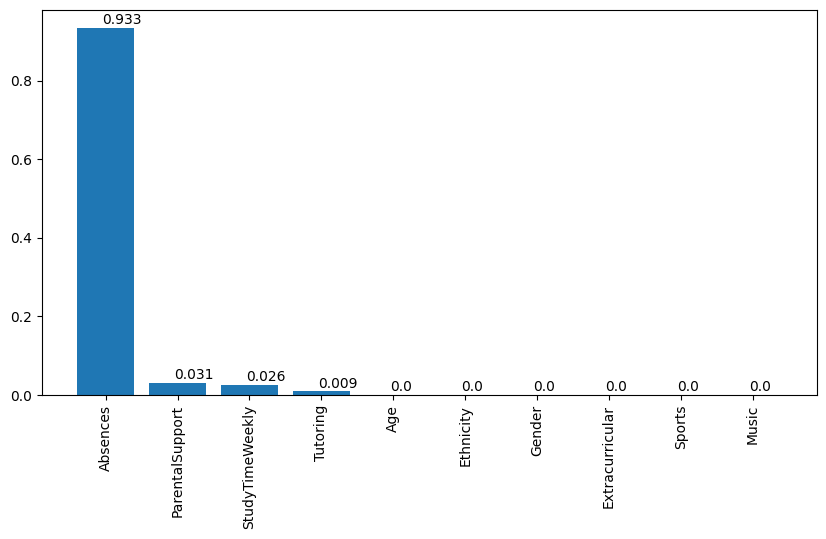

In [172]:
from sklearn.ensemble import AdaBoostRegressor

ADA_BOOST_N_ESTIMATORS = 9

ada_boost = AdaBoostRegressor(n_estimators=ADA_BOOST_N_ESTIMATORS, random_state=10)
ada_boost.fit(GPA_X_train, GPA_y_train)
ada_boost.estimator_weights_

for i in range(ADA_BOOST_N_ESTIMATORS):
    render_png_tree(random_tree.estimators_[i], GPA_X_train.columns, f"bagging_{i}", "renders/bagging")

_,_ = draw_feature_importances(ada_boost, GPA_X_train)

9. Градиентный бустинг

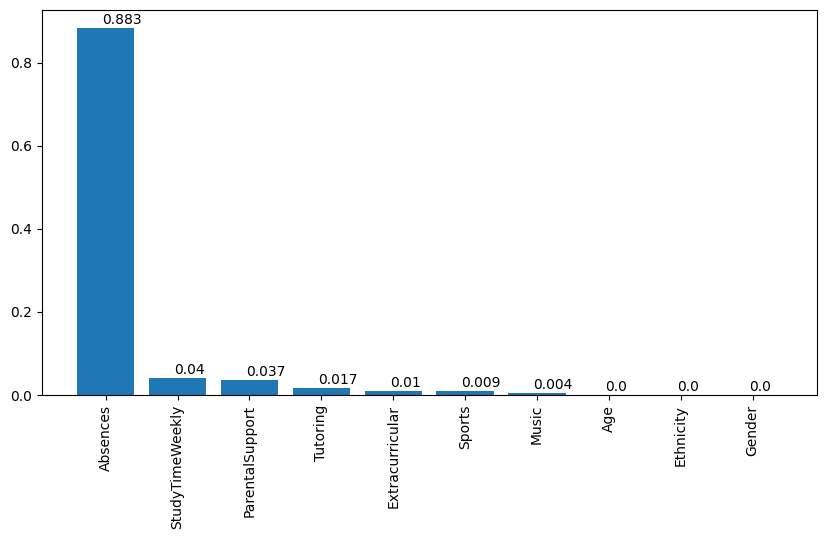

In [173]:
from sklearn.ensemble import GradientBoostingRegressor

gradien_boost = GradientBoostingRegressor(random_state=10)
gradien_boost.fit(GPA_X_train, GPA_y_train)

_,_ = draw_feature_importances(gradien_boost, GPA_X_train)

10. Оценка качетва

In [ ]:
print(f"MAE для полиномиальной, случайного дерева: {mean_absolute_error(random_tree.predict(GPA_X_test), GPA_y_test)}")
print(f"MSE для полиномиальной, случайного дерева: {mean_squared_error(random_tree.predict(GPA_X_test), GPA_y_test)}")
print(f"MAE для полиномиальной, бэггинга: {mean_absolute_error(bagging.predict(GPA_X_test), GPA_y_test)}")
print(f"MSE для полиномиальной, бэггинга: {mean_squared_error(bagging.predict(GPA_X_test), GPA_y_test)}")
print(f"MAE для полиномиальной, AdaBoost: {mean_absolute_error(ada_boost.predict(GPA_X_test), GPA_y_test)}")
print(f"MSE для полиномиальной, AdaBoost: {mean_squared_error(ada_boost.predict(GPA_X_test), GPA_y_test)}")
print(f"MAE для полиномиальной, градиентного бустинга: {mean_absolute_error(gradien_boost.predict(GPA_X_test), GPA_y_test)}")
print(f"MSE для полиномиальной, градиентного бустинга: {mean_squared_error(gradien_boost.predict(GPA_X_test), GPA_y_test)}")

MAE для полиномиальной, бэггинга: 0.3027789134341883


NameError: name 'GPA_y_train_test' is not defined